Epoch 1/50
84/84 [==============================] - 8s 73ms/step - loss: 0.7104 - accuracy: 0.5309 - val_loss: 0.5950 - val_accuracy: 0.8194
Epoch 2/50
84/84 [==============================] - 5s 56ms/step - loss: 0.6472 - accuracy: 0.6133 - val_loss: 0.5900 - val_accuracy: 0.7157
Epoch 3/50
84/84 [==============================] - 5s 58ms/step - loss: 0.6026 - accuracy: 0.6766 - val_loss: 0.5270 - val_accuracy: 0.7860
Epoch 4/50
84/84 [==============================] - 6s 69ms/step - loss: 0.5088 - accuracy: 0.7444 - val_loss: 0.3378 - val_accuracy: 0.9431
Epoch 5/50
84/84 [==============================] - 5s 62ms/step - loss: 0.3343 - accuracy: 0.8573 - val_loss: 0.1731 - val_accuracy: 0.9632
Epoch 6/50
84/84 [==============================] - 4s 53ms/step - loss: 0.2464 - accuracy: 0.9013 - val_loss: 0.2616 - val_accuracy: 0.9298
Epoch 7/50
84/84 [==============================] - 6s 71ms/step - loss: 0.1932 - accuracy: 0.9307 - val_loss: 0.0927 - val_accuracy: 0.9699
Epoch 8/50
84

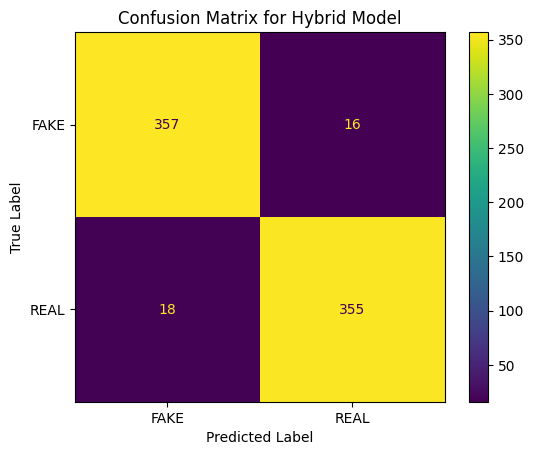

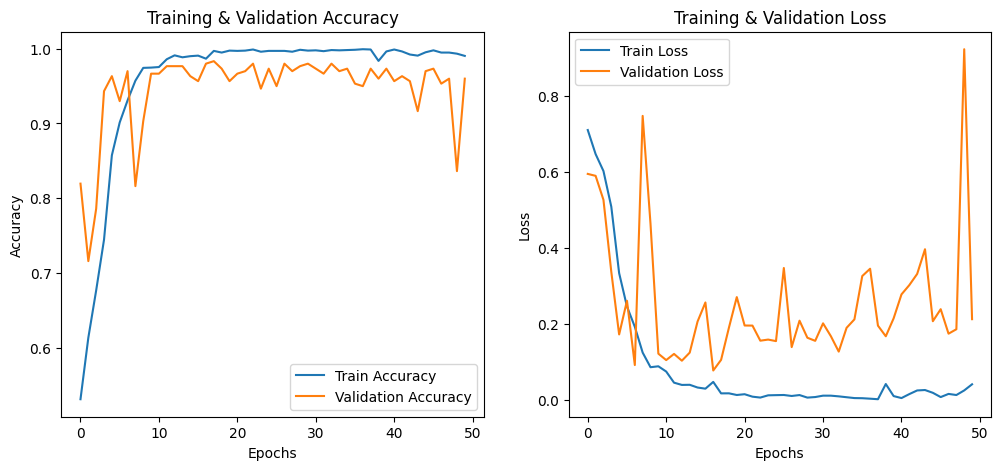

In [2]:
import pandas as pd
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, SimpleRNN, Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Load dataset
file_path = "C:\\Users\\HP\\Downloads\\NEWS.csv"
data = pd.read_csv(file_path)

# Preprocess text data
data['text'] = data['text'].apply(lambda x: x.lower() if pd.notna(x) else "")

# Encode labels
label_encoder = LabelEncoder()
data['label'] = label_encoder.fit_transform(data['label'])
num_classes = len(label_encoder.classes_)

# Prepare data for training
x = data['text']
y = to_categorical(data['label'], num_classes=num_classes)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Tokenization
max_words = 10000  
max_sequence_length = 100  
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(x_train)
x_train_sequences = tokenizer.texts_to_sequences(x_train)
x_test_sequences = tokenizer.texts_to_sequences(x_test)

# Padding sequences
x_train_padded = pad_sequences(x_train_sequences, maxlen=max_sequence_length)
x_test_padded = pad_sequences(x_test_sequences, maxlen=max_sequence_length)

# Define hybrid model
embedding_dim = 100  
RNN_units = 128
MLP_units = 64

def build_hybrid_model():
    model = Sequential()
    model.add(Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_sequence_length))
    model.add(Bidirectional(SimpleRNN(units=RNN_units, dropout=0.2, recurrent_dropout=0.2)))
    model.add(Dense(MLP_units, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(num_classes, activation='softmax'))
    
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# Train model
model = build_hybrid_model()
epochs = 50
batch_size = 32

history = model.fit(x_train_padded, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1)

# Evaluate model
y_pred = model.predict(x_test_padded)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

accuracy = accuracy_score(y_true_classes, y_pred_classes)
precision = precision_score(y_true_classes, y_pred_classes, average='weighted')
recall = recall_score(y_true_classes, y_pred_classes, average='weighted')
f1 = f1_score(y_true_classes, y_pred_classes, average='weighted')

print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=label_encoder.classes_))

# Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap='viridis', values_format='d')
plt.title('Confusion Matrix for Hybrid Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Plot Training & Validation Accuracy and Loss
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training & Validation Accuracy')

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training & Validation Loss')

plt.show()


In [3]:
# Save the trained model in .h5 format
model.save("hybrid_model.h5")
print("Model saved successfully as 'hybrid_model.h5'")


Model saved successfully as 'hybrid_model.h5'


In [4]:
import pickle

# Save the tokenizer
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print("Tokenizer saved successfully as 'tokenizer.pkl'")


Tokenizer saved successfully as 'tokenizer.pkl'


In [5]:
# Save the label encoder
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)
print("Label encoder saved successfully as 'label_encoder.pkl'")


Label encoder saved successfully as 'label_encoder.pkl'
